<a href="https://colab.research.google.com/github/aureamc/A02-eda-and-visualization/blob/main/MyVersion_notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Aurea McIntosh

**Date:** 09/11/26

Dataset loaded successfully! Total rows and columns: (28221, 10)

--- Q2.2: Foreign Gift Amount histogram and description ---
Descriptive statistics for 'Foreign Gift Amount':
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


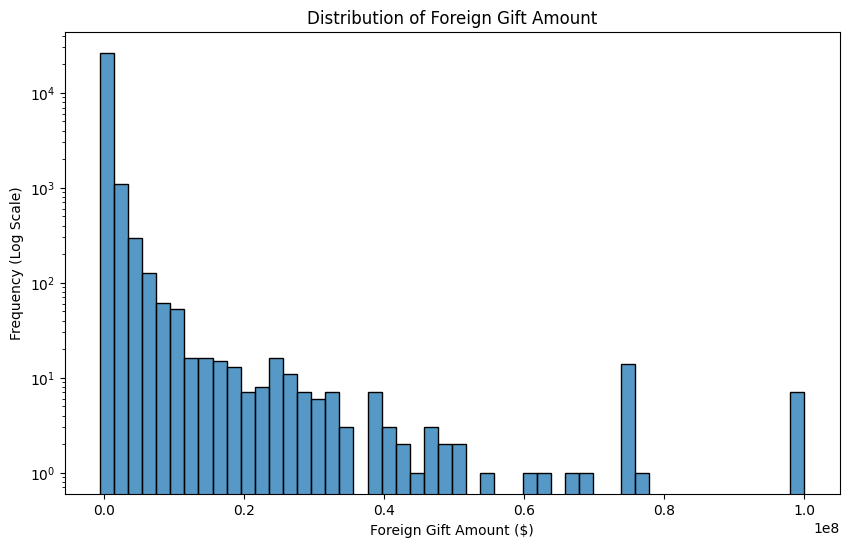


--- Q2.3: Gift Type histogram/value counts and proportion ---
Value counts for 'Gift Type':
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Proportion of each Gift Type:
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


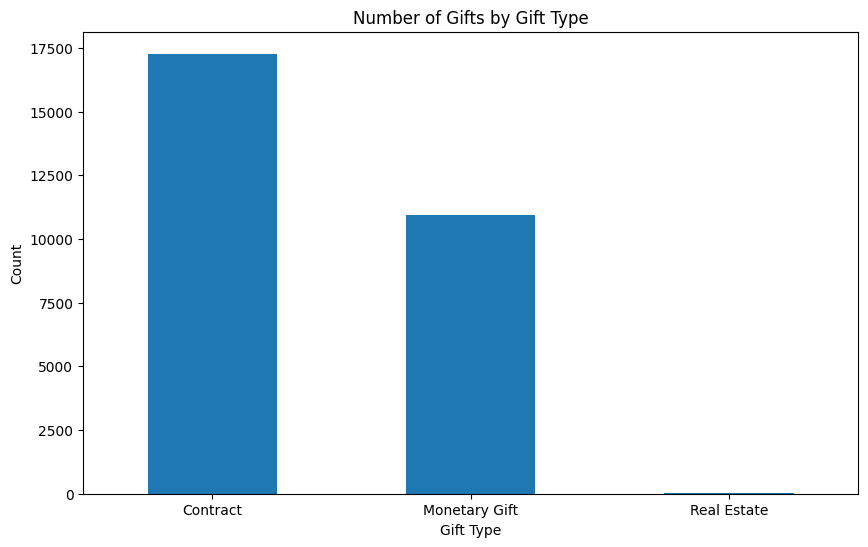


--- Q2.4: Kernel density plots of log of Foreign Gift Amount ---


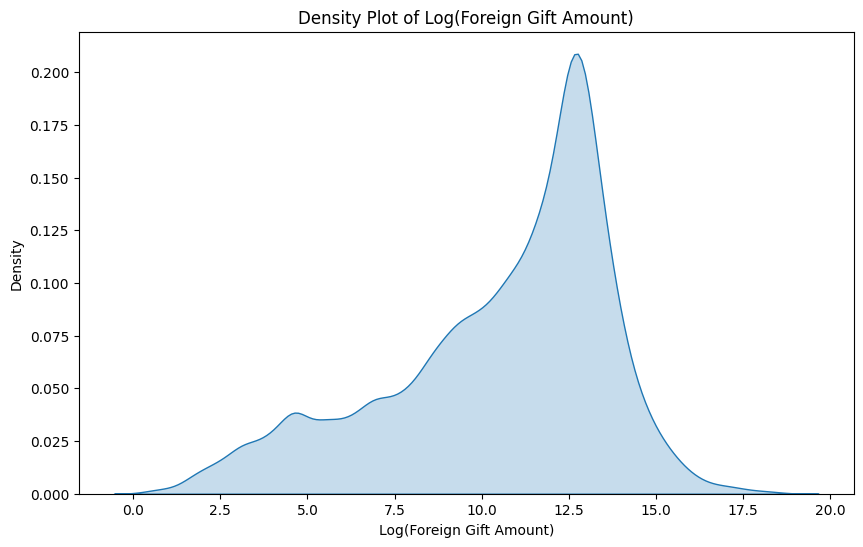

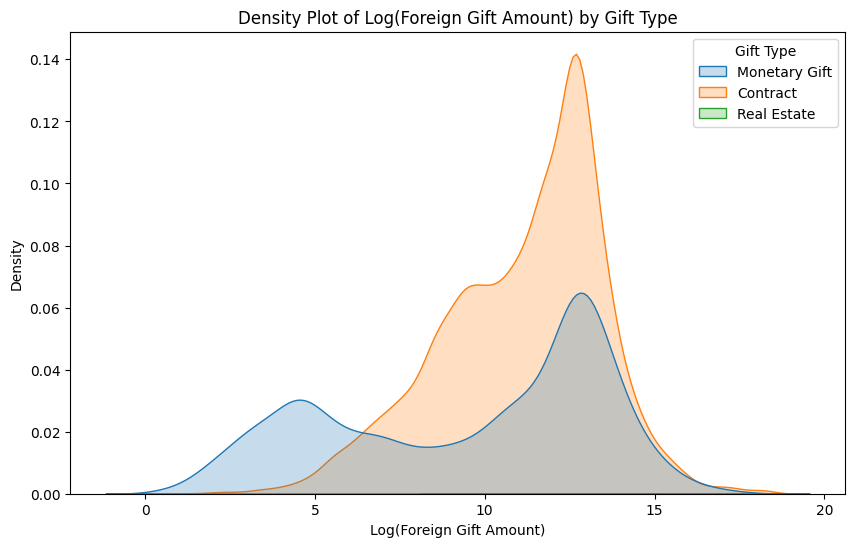


--- Q2.5: Top 15 countries by number of gifts and amount given ---

Top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

Top 15 countries by total amount given ($):
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE 

In [8]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# Q2.1: Load the dataset
# =============================================================================
# Load the CSV file directly into a DataFrame
df = pd.read_csv("./ForeignGifts_edu.csv")
print("Dataset loaded successfully! Total rows and columns:", df.shape)

# Rename 'Foreign Country Name' to 'Country of Giftor' to prevent KeyError in Q2.5
df.rename(columns={'Foreign Country Name': 'Country of Giftor'}, inplace=True)
# Rename 'Foreign Giftor Name' to 'Giftor Name' to prevent KeyError in Q2.6
df.rename(columns={'Foreign Giftor Name': 'Giftor Name'}, inplace=True)


# =============================================================================
# Q2.2: Foreign Gift Amount histogram and description
# =============================================================================
print("\n--- Q2.2: Foreign Gift Amount histogram and description ---")

# Clean 'Foreign Gift Amount' by converting text numbers into real numeric values
df["Foreign Gift Amount"] = pd.to_numeric(
    df["Foreign Gift Amount"], errors="coerce"
)

# Print basic summary statistics (mean, median, min, max)
print("Descriptive statistics for 'Foreign Gift Amount':")
print(df["Foreign Gift Amount"].describe())

# Create a histogram of gift amounts
plt.figure(figsize=(10, 6))
sns.histplot(df["Foreign Gift Amount"], bins=50)
plt.yscale("log")  # Use a log scale so small and large values both fit on the chart
plt.title("Distribution of Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Frequency (Log Scale)")
plt.show()


# =============================================================================
# Q2.3: Gift Type histogram/value counts and proportion
# =============================================================================
print("\n--- Q2.3: Gift Type histogram/value counts and proportion ---")

# Count occurrences of each Gift Type
gift_counts = df["Gift Type"].value_counts()
print("Value counts for 'Gift Type':")
print(gift_counts)

# Calculate proportions (each count divided by the total count)
gift_proportions = df["Gift Type"].value_counts(normalize=True)
print("\nProportion of each Gift Type:")
print(gift_proportions)

# Plot a bar chart of Gift Types
plt.figure(figsize=(10, 6))
gift_counts.plot(kind="bar")
plt.title("Number of Gifts by Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# =============================================================================
# Q2.4: Kernel density plots of log of Foreign Gift Amount
# =============================================================================
print("\n--- Q2.4: Kernel density plots of log of Foreign Gift Amount ---")

# Filter out negative gift amounts before log transformation
df_filtered_for_log = df[df["Foreign Gift Amount"] >= 0].copy()

# Create a log-transformed column using np.log1p (adds 1 so log(0) doesn't cause errors)
df_filtered_for_log["Log Foreign Gift Amount"] = np.log1p(df_filtered_for_log["Foreign Gift Amount"])

# Plot overall density curve for Log Foreign Gift Amount
plt.figure(figsize=(10, 6))
sns.kdeplot(df_filtered_for_log["Log Foreign Gift Amount"], fill=True)
plt.title("Density Plot of Log(Foreign Gift Amount)")
plt.xlabel("Log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

# Plot density curves separated by Gift Type
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_filtered_for_log, x="Log Foreign Gift Amount", hue="Gift Type", fill=True)
plt.title("Density Plot of Log(Foreign Gift Amount) by Gift Type")
plt.xlabel("Log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()


# =============================================================================
# Q2.5: Top 15 countries by number of gifts and amount given
# =============================================================================
print("\n--- Q2.5: Top 15 countries by number of gifts and amount given ---")

# Top 15 countries by total count of gifts
top_countries_count = df["Country of Giftor"].value_counts().head(15)
print("\nTop 15 countries by number of gifts:")
print(top_countries_count)

# Top 15 countries by total dollar amount
top_countries_amount = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .nlargest(15)
)
print("\nTop 15 countries by total amount given ($):")
print(top_countries_amount)


# =============================================================================
# Q2.6: Giftors providing the most money in total
# =============================================================================
print("\n--- Q2.6: Giftors providing the most money in total ---")

# Top 10 giftors providing the highest sum total of gift amounts
top_giftors = (
    df.groupby("Giftor Name")["Foreign Gift Amount"].sum().nlargest(10)
)
print("\nTop giftors by total amount given ($):")
print(top_giftors)
